In [5]:
# Upload your kaggle.json file
from google.colab import files
files.upload()  # This will prompt you to select kaggle.json from your computer

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"atharair","key":"ea8dd728b8608671acdde733b3dafadc"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle

In [7]:
!kaggle datasets download -d uciml/electric-power-consumption-data-set
!unzip electric-power-consumption-data-set.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set
License(s): DbCL-1.0
100% 19.4M/19.4M [00:00<00:00, 69.9MB/s]

Archive:  electric-power-consumption-data-set.zip
  inflating: household_power_consumption.txt  


In [8]:
import pandas as pd

df = pd.read_csv('household_power_consumption.txt', sep=';',
                  parse_dates={'datetime': ['Date', 'Time']},
                  infer_datetime_format=True,
                  na_values=['?'])
df.head()

/tmp/ipykernel_625/19631911.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt', sep=';',
/tmp/ipykernel_625/19631911.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('household_power_consumption.txt', sep=';',
/tmp/ipykernel_625/19631911.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('household_power_consumption.txt', sep=';',


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [9]:
!ls

electric-power-consumption-data-set.zip  kaggle.json
household_power_consumption.txt		 sample_data


In [10]:
df.head(100)

,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
95,2006-12-16 18:59:00,4.224,0.090,231.96,18.2,0.0,1.0,16.0
96,2006-12-16 19:00:00,4.070,0.088,231.99,17.4,0.0,1.0,17.0
97,2006-12-16 19:01:00,3.612,0.090,232.36,15.6,0.0,2.0,16.0
98,2006-12-16 19:02:00,3.458,0.090,232.71,14.8,0.0,1.0,17.0


In [11]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


,0
datetime,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [12]:
# Drop missing values
df = df.dropna()

# Set datetime as index
df.set_index('datetime', inplace=True)

# Resample to daily average
daily_df = df.resample('D').mean()

daily_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


In [13]:
daily_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


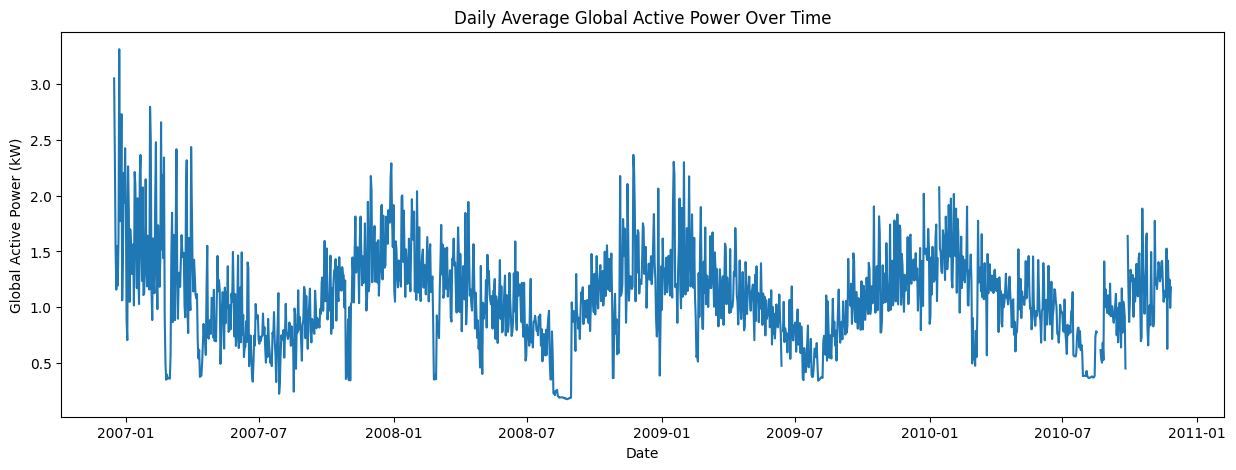

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df['Global_active_power'])
plt.title('Daily Average Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.show()

In [15]:
daily_df['month'] = daily_df.index.month
daily_df['day_of_week'] = daily_df.index.dayofweek  # 0=Monday, 6=Sunday
daily_df['is_weekend'] = daily_df['day_of_week'].isin([5,6]).astype(int)
daily_df['year'] = daily_df.index.year

daily_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,month,day_of_week,is_weekend,year
datetime,,,,,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394,12,5,1,2006
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583,12,6,1,2006
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722,12,0,0,2006
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472,12,1,0,2006
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972,12,2,0,2006


In [16]:
daily_df.isnull().sum()

,0
Global_active_power,9
Global_reactive_power,9
Voltage,9
Global_intensity,9
Sub_metering_1,9
Sub_metering_2,9
Sub_metering_3,9
month,0
day_of_week,0
is_weekend,0


In [17]:
daily_df = daily_df.dropna()

In [18]:
from sklearn.model_selection import train_test_split

# Features and target
X = daily_df[['month', 'day_of_week', 'is_weekend', 'year',
              'Voltage', 'Global_intensity',
              'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']]
y = daily_df['Global_active_power']

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(X_train.shape, X_test.shape)

(1146, 9) (287, 9)


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [20]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)


In [22]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

MAE: 0.011
RMSE: 0.014
R² Score: 0.998


In [24]:
df.head(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


In [25]:
daily_df['lag_1'] = daily_df['Global_active_power'].shift(1)   # yesterday
daily_df['lag_7'] = daily_df['Global_active_power'].shift(7)

In [26]:
daily_df = daily_df.dropna()

In [27]:
X = daily_df[['month', 'day_of_week', 'is_weekend', 'year', 'lag_1', 'lag_7']]
y = daily_df['Global_active_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(X_train.shape, X_test.shape)

(1140, 6) (286, 6)


In [28]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [29]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

MAE: 0.188
RMSE: 0.257
R² Score: 0.335


In [30]:
daily_df['lag_2'] = daily_df['Global_active_power'].shift(2)
daily_df['lag_3'] = daily_df['Global_active_power'].shift(3)
daily_df['rolling_mean_7'] = daily_df['Global_active_power'].shift(1).rolling(window=7).mean()

/tmp/ipykernel_625/2966254569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_df['lag_2'] = daily_df['Global_active_power'].shift(2)
/tmp/ipykernel_625/2966254569.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_df['lag_3'] = daily_df['Global_active_power'].shift(3)
/tmp/ipykernel_625/2966254569.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [32]:
daily_df = daily_df.dropna()

In [33]:

X = daily_df[['month', 'day_of_week', 'is_weekend', 'year',
              'lag_1', 'lag_2', 'lag_3', 'lag_7', 'rolling_mean_7']]
y = daily_df['Global_active_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(X_train.shape, X_test.shape)

(1135, 9) (284, 9)


In [34]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [35]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

MAE: 0.176
RMSE: 0.242
R² Score: 0.393


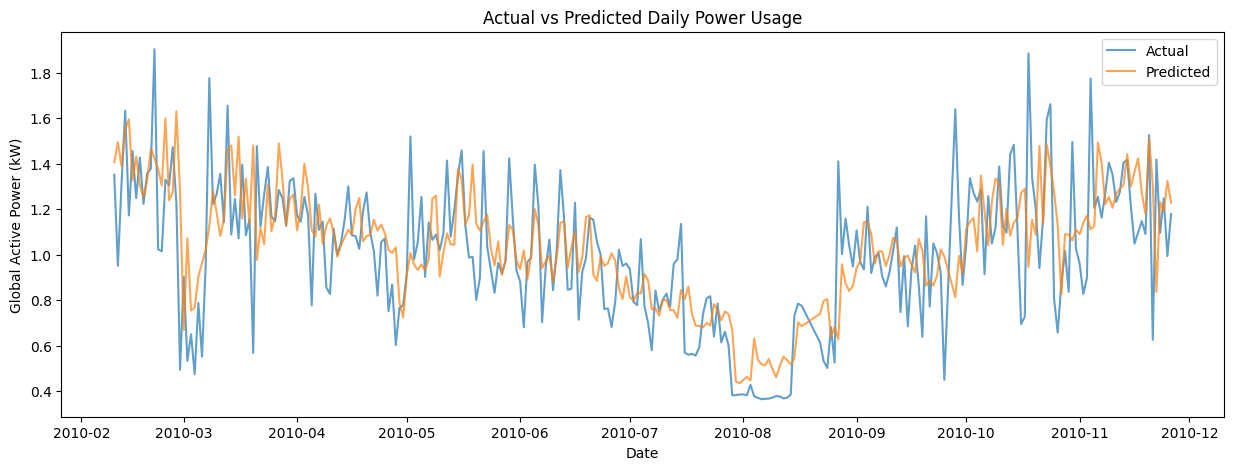

In [40]:
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Daily Power Usage')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()

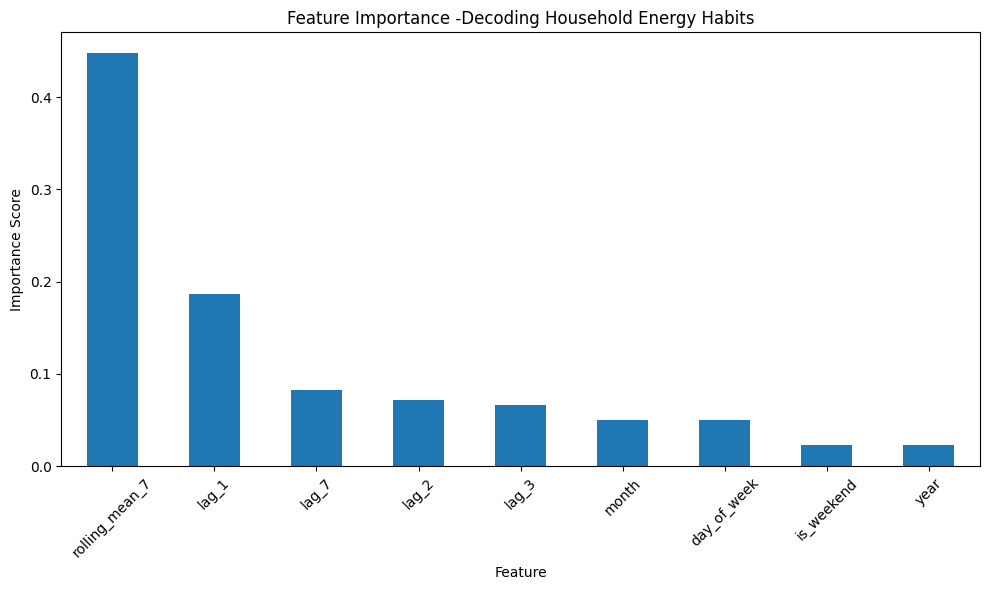

rolling_mean_7    0.447750
lag_1             0.186622
lag_7             0.082283
lag_2             0.072079
lag_3             0.066757
month             0.049546
day_of_week       0.049545
is_weekend        0.022753
year              0.022664
dtype: float64


In [42]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title('Feature Importance -Decoding Household Energy Habits')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(feature_importance)